# RASCUNHO
Use esse arquivo para testra o que você está desenvolvendo. Ajuda muito conseguir visualizar o resultado do que você está fazendo. Você pode importar de core/ as funções que precisar e, quando estiver pronto, mover para o respectivo arquivo de core/

ex: fazer aqui o equalize() e depois mover para equalize.py

In [63]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from typing import Final, Any
from numpy.typing import NDArray
from numpy import uint8, float64, intp
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from PIL.Image import Image as IMG

## save() and load()

In [64]:
def load(path: str) -> IMG:
    return Image.open(path).convert('L') # isso converte para uma escala de cinza de 8 bits


img: IMG = load('lobao.jpg')

In [65]:
def save(img: IMG, path: str) -> None:
    img.save(path)

save(img, 'result.jpg')

### Tralhas

min: 0, max: 255


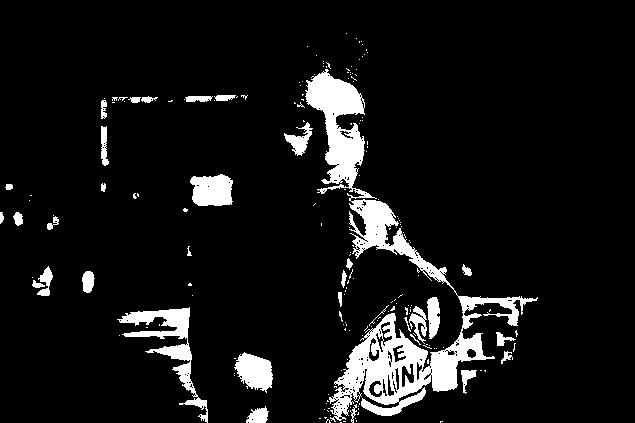

In [66]:
arr:    NDArray[uint8]   = np.array(img, dtype=np.uint8)

lut:    Final[list[int]] = [0 if i < 128 else 255 for i in range(256)]   # look up table: transformação ponto a ponto
img_bw: IMG              = img.point(lut, mode='L')                      # aplicando um tipo de threshold

print(f'min: {arr.min()}, max: {arr.max()}')
img_bw

## get_histogram()

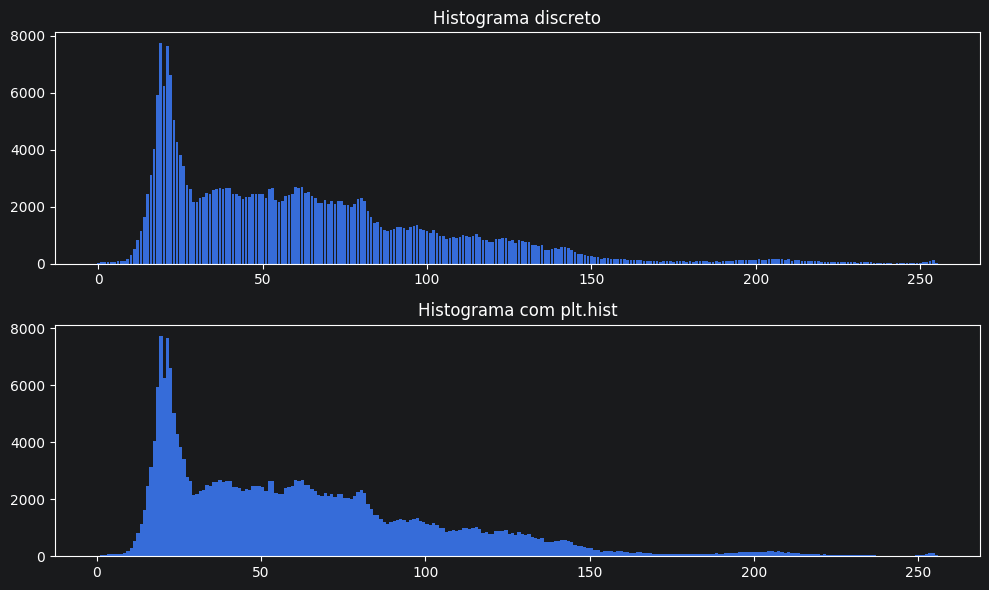

In [67]:
def get_histogram(arr: NDArray[np.uint8]) -> tuple[NDArray[np.int64], Figure]:

    fig: Figure = Figure(figsize=(10, 6))
    ax1: Axes = fig.add_subplot(2, 1, 1)
    ax2: Axes = fig.add_subplot(2, 1, 2)

    hist_data: NDArray[np.int64] = np.bincount(arr.ravel(), minlength=256)

    ax1.set_title("Histograma discreto")
    ax1.bar(range(256), hist_data)

    ax2.set_title("Histograma com plt.hist")
    ax2.hist(arr.ravel(), bins=256, range=(0, 256))

    fig.tight_layout()
    return hist_data, fig

fig: Figure
hist: list[int]
hist_data, fig = get_histogram(arr)
hist

## compute_pdf()

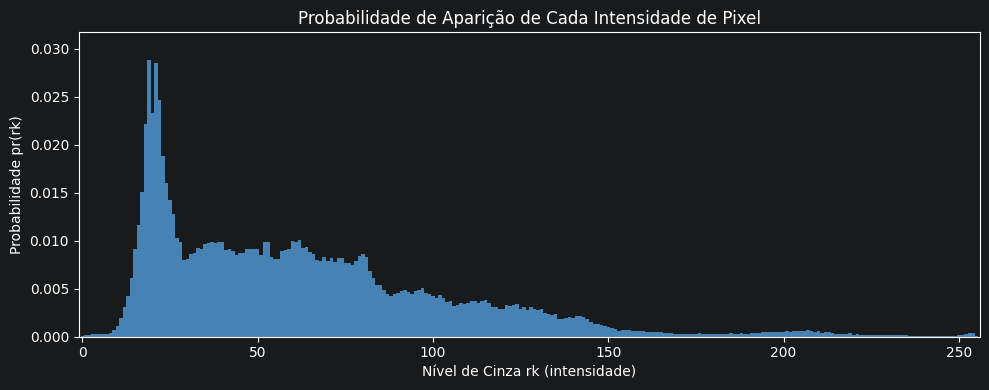

In [73]:
def compute_pdf(vector_image: NDArray[uint8]) -> tuple[NDArray[float64], Figure]:

    vector_image = vector_image.astype(uint8)

    pixels_appears: NDArray[intp]    = np.bincount(vector_image.ravel(), minlength=256)
    pdf_float:      NDArray[float64] = pixels_appears / vector_image.size

    fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))  # ← back to plt
    plt.close(fig)                                    # ← prevents auto-display

    ax1.bar(np.arange(256), pdf_float, width=1.0, color='steelblue')
    ax1.set_xlim(-1, 256)
    ax1.set_ylim(0, pdf_float.max() * 1.1)
    ax1.set_title('Probabilidade de Aparição de Cada Intensidade de Pixel')
    ax1.set_xlabel('Nível de Cinza rk (intensidade)')
    ax1.set_ylabel('Probabilidade pr(rk)')
    fig.tight_layout()

    return pdf_float, fig


pdf_values, fig = compute_pdf(arr)
fig

## compute_cdf()

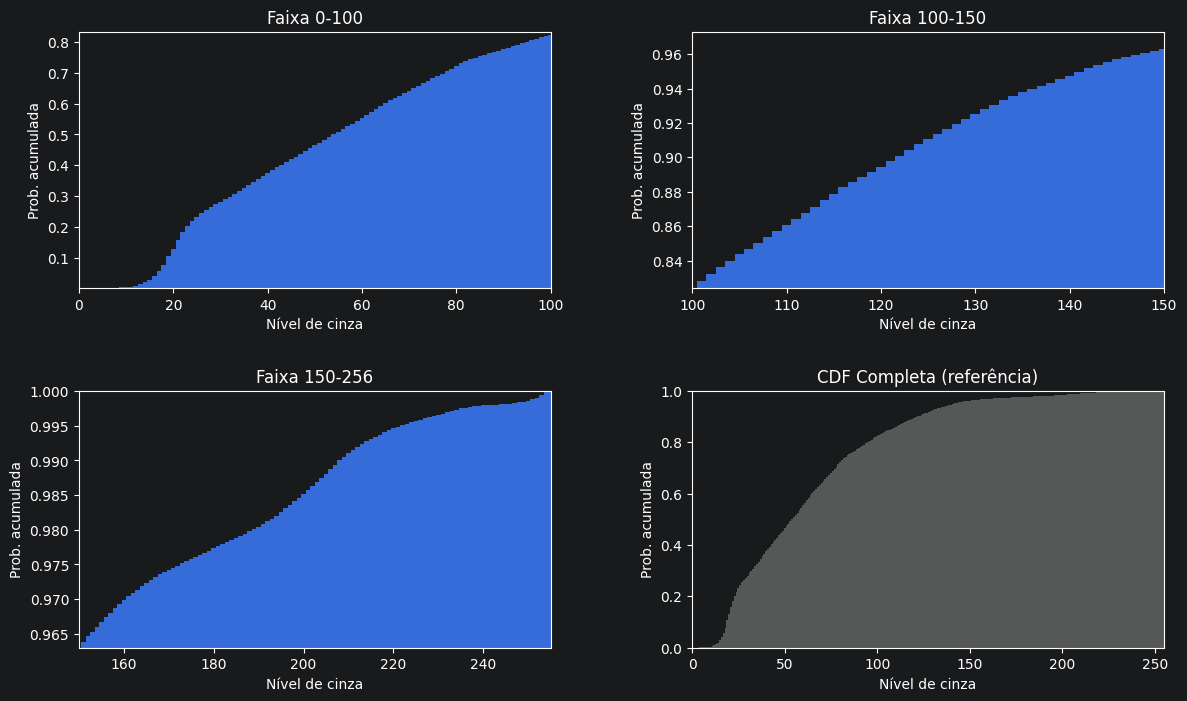

In [69]:
def compute_cdf(vector_image: NDArray[uint8], plot: bool = True) -> tuple[Figure | None, NDArray[float64]]:
    
    pdf_values: NDArray[float64] = compute_pdf(vector_image)[0]
    cdf_values: NDArray[float64] = pdf_values.cumsum()

    if not plot:
        return (None, cdf_values)

    fig: Figure = Figure(figsize=(14, 8))

    gs = gridspec.GridSpec(nrows=2, ncols=2, 
                           figure=fig, 
                           width_ratios=[1, 1], wspace=0.3, 
                           height_ratios=[1, 1], hspace=0.4)

    ax1: Axes = fig.add_subplot(gs[0,0])
    ax2: Axes = fig.add_subplot(gs[0,1])
    ax3: Axes = fig.add_subplot(gs[1,0])
    ax4: Axes = fig.add_subplot(gs[1,1])

    sections = [
        (ax1, 0, 101, 'Faixa 0-100'),
        (ax2, 100, 151, 'Faixa 100-150'),
        (ax3, 150, 256, 'Faixa 150-256'),
    ]

    for ax, start, end, title in sections:
        x = np.arange(start, end)
        ax.bar(x, cdf_values[start:end], width=1)

        ax.set_title(title)
        ax.set_xlabel("Nível de cinza")
        ax.set_ylabel("Prob. acumulada")
        ax.set_xlim(start, end - 1)
        ax.set_ylim(cdf_values[start], min(cdf_values[end - 1] + 0.01, 1.0))

    
    ax4.bar(np.arange(256), cdf_values, width=1, color="gray", alpha=0.6)
    ax4.set_title("CDF Completa (referência)")

    ax4.set_xlabel("Nível de cinza")
    ax4.set_ylabel("Prob. acumulada")
    ax4.set_xlim(0, 255)
    ax4.set_ylim(0, 1)

    return (fig, cdf_values)


fig: Figure
cdf_values: NDArray[float64]
fig, cdf_values = compute_cdf(arr)
fig

## equalize()

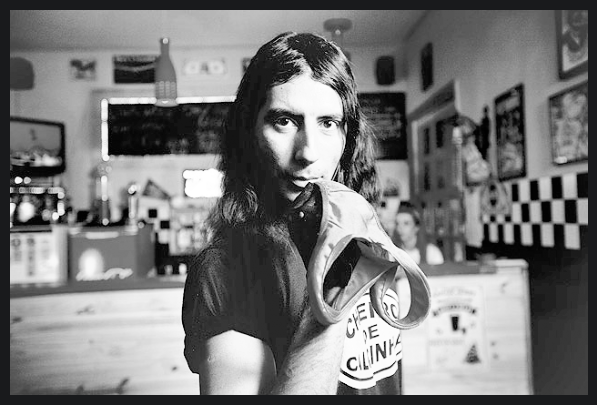

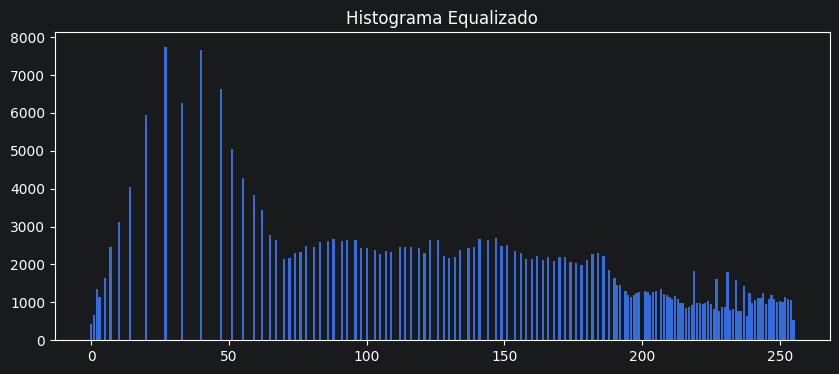

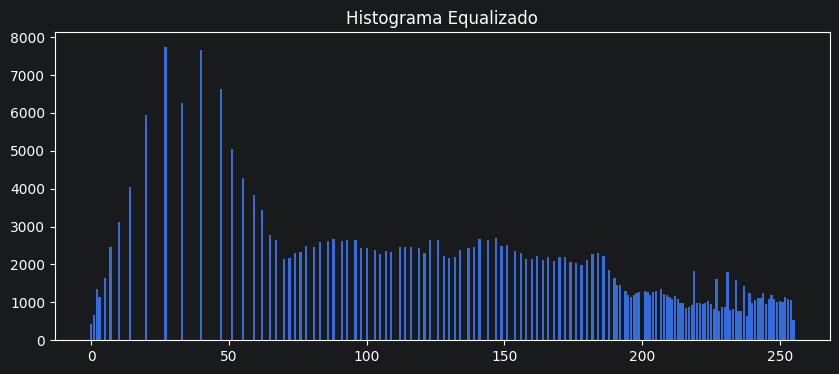

In [70]:
def equalize(arr: NDArray[uint8]) -> tuple[IMG, NDArray[uint8], Figure]:
    _, cdf_values = compute_cdf(arr, plot=False)

    lut_equalized: NDArray[uint8] = np.round(cdf_values * 255).astype(np.uint8)
    arr_equalized: NDArray[uint8] = lut_equalized[arr]
    img_equalized: IMG = Image.fromarray(arr_equalized, mode='L')

    hist_equalized: NDArray[uint8] = np.bincount(arr_equalized.ravel(), minlength=256)

    fig: Figure = Figure(figsize=(10, 5))
    ax = fig.add_subplot(1, 1, 1)
    ax.imshow(arr_equalized, cmap='gray', vmin=0, vmax=255)
    ax.axis('off')

    return img_equalized, hist_equalized, fig


img_equalized, hist_equalized, fig_equalized = equalize(arr)

display(fig_equalized)

fig_hist, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(256), hist_equalized)
ax.set_title("Histograma Equalizado")
display(fig_hist)

## match()

In [79]:
def match(arr_orig: NDArray[uint8], img_ref: IMG) -> tuple[IMG, NDArray[uint8], Figure]:

    from core.basics import compute_cdf

    arr_ref: NDArray[uint8] = np.array(img_ref, dtype=np.uint8)

    _, cdf_orig = compute_cdf(arr_orig, plot=False)
    _, cdf_ref  = compute_cdf(arr_ref,  plot=False)

    lut_match: NDArray[uint8] = np.zeros(256, dtype=np.uint8)

    for g_orig in range(256):
        differences = np.abs(cdf_ref - cdf_orig[g_orig])
        g_ref = np.argmin(differences)
        lut_match[g_orig] = g_ref

    arr_matched: NDArray[uint8] = lut_match[arr_orig]
    img_matched: IMG = Image.fromarray(arr_matched, mode='L')

    hist_matched: NDArray[np.uint8] = np.bincount(arr_matched.ravel(), minlength=256)

    fig: Figure = Figure(figsize=(10, 5))
    ax = fig.add_subplot(1, 1, 1)
    ax.imshow(arr_matched, cmap='gray', vmin=0, vmax=255)
    ax.axis('off')

    return img_matched, hist_matched, fig

img_ref = load('reference.jpg')

img_matched, hist_matched, fig_matched = match(arr, img_ref)

display(fig_matched)

fig_hist, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(256), hist_matched)
ax.set_title("Histograma após Match")
display(fig_hist)

AttributeError: 'Figure' object has no attribute 'cumsum'

## thresholding

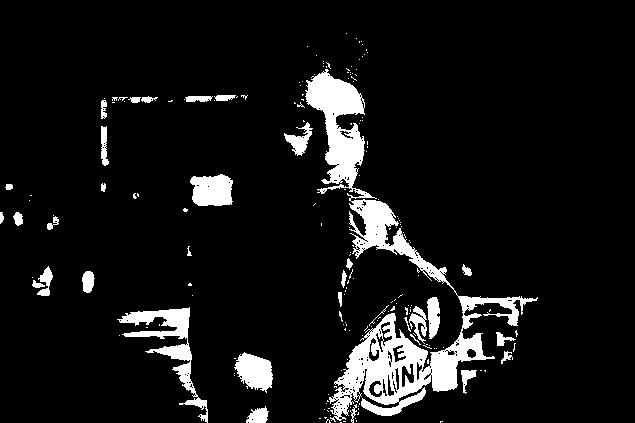

In [76]:
def threshold(vector_image: NDArray[uint8], T: int = 128) -> tuple[IMG, NDArray[float64], Figure]:

    from core.basics import compute_pdf

    result: NDArray[uint8]
    pdf:    NDArray[float64]

    result = np.where(vector_image >= T, 255, 0).astype(uint8)
    pdf, _ = compute_pdf(result)

    fig: Figure
    ax:  Axes

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(np.arange(256), pdf, width=1, color='steelblue')
    ax.axvline(x=T, color='red', linestyle='--', label=f'T = {T}')
    ax.set_xlim(-1, 256)
    ax.set_ylim(0, pdf.max() * 1.1)
    ax.set_title(f'Histograma Resultante  (T={T})')
    ax.set_xlabel('Nível de Cinza ($r_k$)')
    ax.set_ylabel('Probabilidade $p(r_k)$')
    ax.legend()
    fig.tight_layout()
    plt.close(fig)

    pil_image: IMG = Image.fromarray(result, mode='L')

    return (pil_image, pdf, fig)

img, pdf_result, fig = threshold(arr)
img